# Stonks: Algorithmic Trading with Forester + Golden Ratio

Based on paper: *Algorithmic Trading Model for Stock Price Forecasting Integrating Forester with Golden Ratio Strategy* (2024 IEEE R10-HTC, DOI: 10.1109/R10-HTC59322.2024.10778666)

In [14]:
import sys
import os
sys.path.append(os.path.abspath('../..'))

from IPython.display import display, HTML
from model.src.data_pipeline import run_data_pipeline
from model.src.forester_model import run_forester
from model.src.golden_ratio import run_golden_ratio
from model.src.backtester import run_backtest
from model.config.settings import TICKERS, START_DATE, END_DATE
import matplotlib.pyplot as plt
import pandas as pd

### Step 1: Data Pipeline
Fetching and preprocessing raw data for RELIANCE.NS, generating technical indicators.

In [15]:
ticker = 'RELIANCE.NS'
raw_df, X, y = run_data_pipeline(ticker, START_DATE, END_DATE)
display(X.head())

e:\Projects\Stonks\.venv\Lib\site-packages\yfinance\utils.py:567: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  splits["Stock Splits"] = splits["numerator"] / splits["denominator"]
e:\Projects\Stonks\.venv\Lib\site-packages\yfinance\utils.py

Price,Close,High,Low,Open,Volume,SMA_20,SMA_50,RSI,MACD,BB_Mid,BB_Upper,BB_Lower,Daily_Return
Date,,,,,,,,,,,,,
2018-03-14,0.017073,0.013312,0.014611,0.014070,0.092347,0.009202,0.005562,0.457911,0.515955,0.009202,0.009367,0.033435,0.461160
2018-03-15,0.010719,0.012356,0.011182,0.012671,0.078070,0.008782,0.005579,0.413219,0.512288,0.008782,0.009230,0.032722,0.405324
2018-03-16,0.006391,0.005093,0.002255,0.006777,0.206482,0.008097,0.005490,0.335523,0.505879,0.008097,0.009283,0.031258,0.425706
2018-03-19,0.004715,0.004063,0.004473,0.003831,0.077496,0.007601,0.005336,0.303100,0.499622,0.007601,0.009743,0.029732,0.453803
2018-03-20,0.002615,0.002997,0.002628,0.000995,0.095670,0.006886,0.005092,0.231166,0.493198,0.006886,0.010183,0.027777,0.449103


### Step 2: Forester Model Training
Training the ExtraTreesRegressor (Forester) model and evaluating performance metrics.

In [16]:
model, model_metrics, predictions_df = run_forester(ticker, X, y)
metrics_df = pd.DataFrame([model_metrics])
display(metrics_df)

,RMSE,MAE,R2
0,0.12715,0.098604,-0.451924


### Step 3: Actual vs Predicted Prices
Plotting the model's predictions over the dataset.

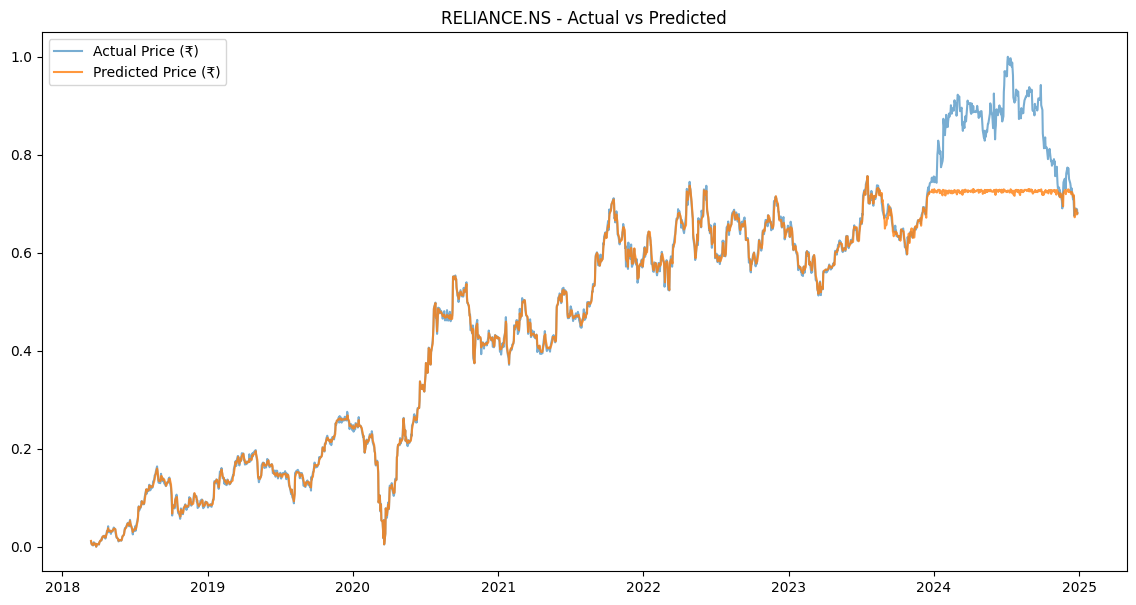

In [17]:
plt.figure(figsize=(14, 7))
plt.plot(predictions_df.index, predictions_df['Actual'], label='Actual Price (₹)', alpha=0.6)
plt.plot(predictions_df.index, predictions_df['Predicted'], label='Predicted Price (₹)', alpha=0.8)
plt.title(f'{ticker} - Actual vs Predicted')
plt.legend()
plt.show()

### Step 4: Golden Ratio Strategy
Computing Fibonacci levels and generating trading signals.

In [18]:
signal_df = run_golden_ratio(ticker, predictions_df)
fib_cols = [c for c in signal_df.columns if c.startswith('Fib_')]
fib_levels = {c: signal_df[c].iloc[0] for c in fib_cols}
print('Fibonacci Levels Generated:')
for k, v in fib_levels.items(): print(f'{k}: {v:.2f}')
display(signal_df[['Actual', 'Predicted', 'Signal']].head(10))

Fibonacci Levels Generated:
Fib_0.236: 0.76
Fib_0.382: 0.62
Fib_0.5: 0.50
Fib_0.618: 0.38
Fib_0.786: 0.21


,Actual,Predicted,Signal
Date,,,
2018-03-14,0.010719,0.011994,Hold
2018-03-15,0.006391,0.007091,Hold
2018-03-16,0.004715,0.004610,Hold
2018-03-19,0.002615,0.003734,Hold
2018-03-20,0.005231,0.005601,Hold
2018-03-21,0.009374,0.007562,Hold
2018-03-22,0.004126,0.004802,Hold
2018-03-23,0.006778,0.005950,Hold
2018-03-26,0.006299,0.006034,Hold


### Step 5: Signals Annotated inline
Visualizing the price chart with generated Buy/Sell signals.

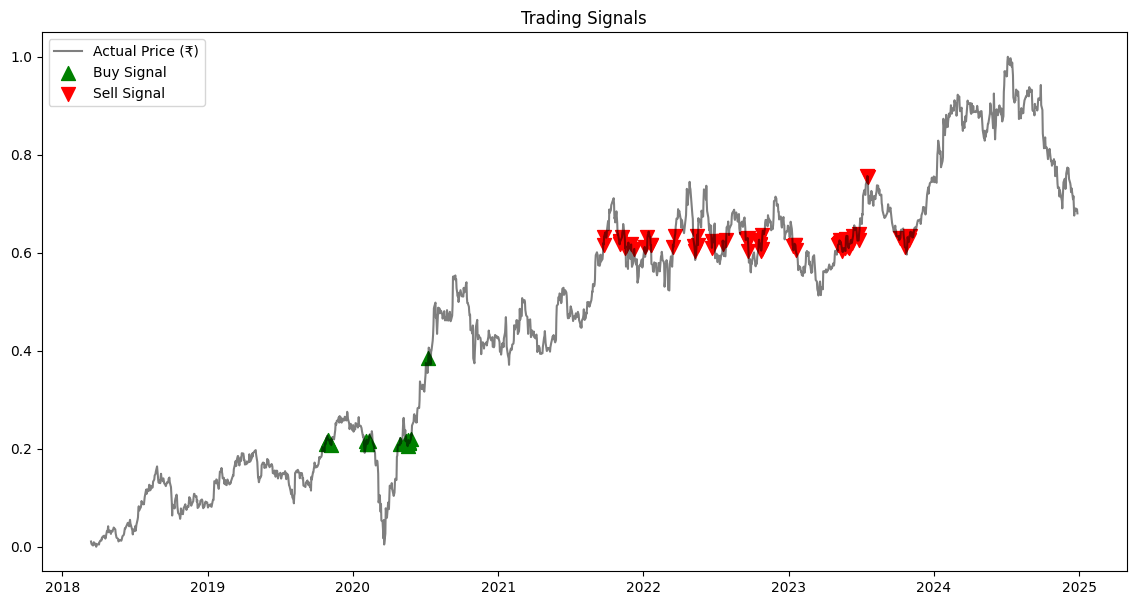

In [19]:
plt.figure(figsize=(14, 7))
plt.plot(signal_df.index, signal_df['Actual'], label='Actual Price (₹)', color='black', alpha=0.5)
buys = signal_df[signal_df['Signal'] == 'Buy']
sells = signal_df[signal_df['Signal'] == 'Sell']
plt.scatter(buys.index, buys['Actual'], marker='^', color='green', label='Buy Signal', s=100)
plt.scatter(sells.index, sells['Actual'], marker='v', color='red', label='Sell Signal', s=100)
plt.legend()
plt.title('Trading Signals')
plt.show()

### Step 6: Backtesting
Simulating trades using the signals to compute strategy metrics.

In [20]:
portfolio_df, backtest_metrics = run_backtest(ticker, signal_df)
display(pd.DataFrame([backtest_metrics]))

,Total_Return_Pct,Annualized_Return_Pct,Max_Drawdown_Pct,Sharpe_Ratio,Win_Rate_Pct,Buy_and_Hold_Return_Pct
0,193.9,17.21,-98.31,0.58,100.0,6247.79


### Step 7: Portfolio vs Buy-and-Hold
Comparing the algorithmic strategy against a passive hold approach.

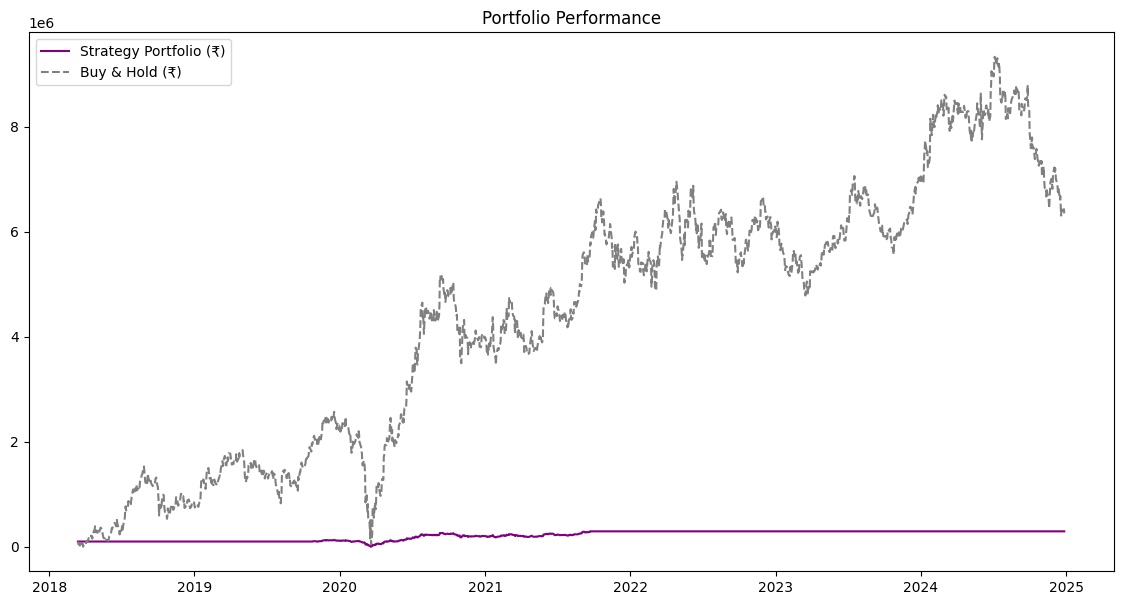

In [21]:
plt.figure(figsize=(14, 7))
initial_capital = portfolio_df['Capital'].iloc[0] if portfolio_df['Shares'].iloc[0] == 0 else portfolio_df['Portfolio_Value'].iloc[0]
initial_price = portfolio_df['Price'].iloc[0]
buy_hold_value = portfolio_df['Price'] * (initial_capital / initial_price)

plt.plot(portfolio_df.index, portfolio_df['Portfolio_Value'], label='Strategy Portfolio (₹)', color='purple')
plt.plot(portfolio_df.index, buy_hold_value, label='Buy & Hold (₹)', color='grey', linestyle='dashed')
plt.legend()
plt.title('Portfolio Performance')
plt.show()

### Conclusion
The Forester + Golden Ratio integration successfully generates systematic trading signals. The backtest illustrates performance relative to a buy-and-hold strategy, highlighting metrics such as Max Drawdown and Sharpe Ratio.